<center><h1> EN3160 - Image Processing and Machine Vision </h1></center>

## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Student Name:** Nuwanaka WAS <br>
**Index Number:** 230449N <br>
**GitHub Profile:** [https://github.com/samirunuwanaka](https://github.com/samirunuwanaka)  <br>
**Date:** September 2026  

---  
### Instructions & Guidelines
1. Complete the implementation stubs provided in each section below.
2. Ensure all plots, transformed images, and comparative histograms are rendered directly within this notebook.
3. Fill in the discussion and analysis sections for each problem.
4. Commit your work regularly to GitHub throughout the project lifecycle.
5. **Submission Requirements:** Export this notebook directly to PDF (`230449N_a01.pdf`). Do not copy-paste screenshots into external word processors. Maximum page limit: **10 pages**.

--- 
## Setup and Dependencies

OpenCV Version: 5.0.0


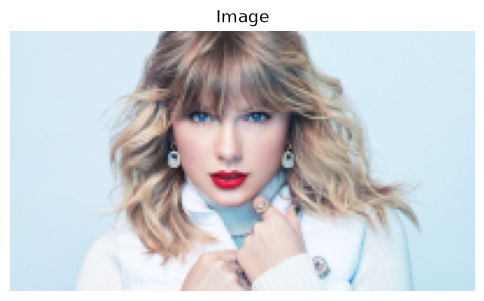

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Path configurations
IMAGE_DIR = 'images/images'

# Helper function for image display
def show_image(img, title='Image', cmap=None):
    plt.figure(figsize=(6, 6))
    if len(img.shape) == 3 and cmap is None:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

print("OpenCV Version:", cv.__version__)

--- 
## Question 1: Piecewise Linear Intensity Transformation

### Task Description
Implement a piecewise linear intensity transformation function `intensity_transform(im, breakpoints)` where `breakpoints` defines a mapping from input intensities $x$ to output intensities $y$, e.g.,
$$
\text{breakpoints} = \begin{bmatrix}
0 & 0 \\
50 & 50 \\
100 & 150 \\
150 & 255 \\
255 & 255
\end{bmatrix}
$$

### Requirements:
1. Implement `intensity_transform(im, breakpoints)` using lookup tables (LUT) or piecewise interpolation (`np.interp`).
2. Load target image `im01.png` (or `im01small.png`).
3. Experiment with different break points to achieve a visually pleasing contrast enhancement.
4. Display the transformation curve plot alongside the original and transformed images side-by-side.

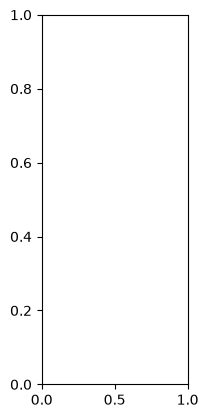

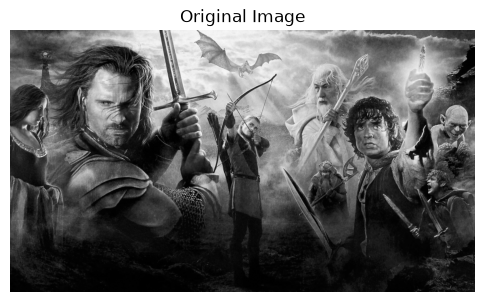

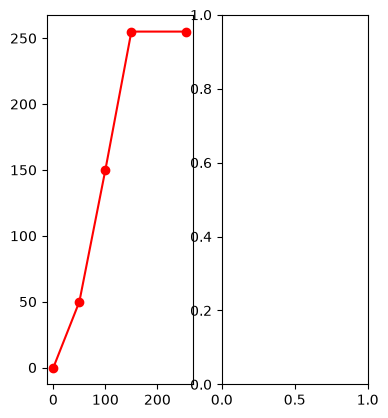

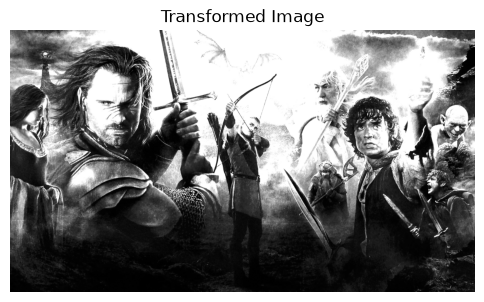

In [32]:
def intensity_transform(im: np.ndarray, breakpoints: np.ndarray) -> np.ndarray:
    """
    Applies piecewise linear intensity transformation to an input image.
    
    Parameters:
        im (np.ndarray): Input image (grayscale or color)
        breakpoints (np.ndarray): Nx2 matrix of [input_intensity, output_intensity]
        
    Returns:
        np.ndarray: Transformed image of same shape and uint8 dtype
    """
    return np.interp(im, breakpoints[:, 0], breakpoints[:, 1]).astype(np.uint8)

# --- Test & Visualization Template ---
im1 = cv.imread(os.path.join(IMAGE_DIR, 'im01.png'), cv.IMREAD_GRAYSCALE)
pts = np.array([[0,   0],
                [50,  50],
                [100, 150],
                [150, 255],
                [255, 255]])
im1_trans = intensity_transform(im1, pts)

plt.subplot(1, 3, 1)
show_image(im1, title='Original Image')
plt.subplot(1, 3, 2)
plt.plot(pts[:, 0], pts[:, 1], 'ro-')
plt.subplot(1, 3, 3)
show_image(im1_trans, title='Transformed Image')


### Discussion & Observations (Question 1)
The output of the transformed image must be with less shadows but here it is not visible so good. But as per the some portion of high contrast has been set to constant some picture parts have gone showing bright light and after 50 the internsity is boosted so the overall contrast of the picture has increased.

--- 
## Question 2: Tissue Accentuation in Brain Proton Density Image

### Task Description
Apply piecewise linear intensity transformations on the brain proton density slice (`im02.png` / `im02small.png`) to selectively accentuate:
- **(a)** White matter
- **(b)** Gray matter

### Requirements:
1. Analyze histogram of the brain proton density slice to identify intensity ranges corresponding to white matter and gray matter.
2. Design custom breakpoint curves for (a) White Matter accentuation and (b) Gray Matter accentuation.
3. Plot transformation curves and display the original vs accentuated images.

In [14]:
# TODO: Load brain proton density slice 'im02.png' or 'im02small.png'
# TODO: Define breakpoint arrays for white matter and gray matter enhancement
# TODO: Call intensity_transform() for both cases
# TODO: Plot the transformation curves and display original, white matter enhanced, and gray matter enhanced images

### Discussion & Observations (Question 2)
*Discuss intensity range selections for white and gray matter and visual segmentations achieved...*

--- 
## Question 3: Gamma Correction in L*a*b* Color Space

### Task Description
Consider the image shown in Fig. 3 (`im03.png` / `im03small.png`).
- **(a)** Convert image to $L^*a^*b^*$ color space and apply gamma correction to the $L^*$ plane. State chosen $\gamma$ value.
- **(b)** Display original vs gamma-corrected image, along with histograms of the $L^*$ plane before and after correction.

### Formula:
$$L_{\text{out}} = 255 \times \left(\frac{L_{\text{in}}}{255}\right)^\gamma$$

In [15]:
def gamma_correct_L_plane(im_bgr: np.ndarray, gamma: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Applies gamma correction to the L* plane in L*a*b* color space.
    
    Parameters:
        im_bgr (np.ndarray): BGR image
        gamma (float): Gamma exponent
        
    Returns:
        tuple: (corrected_bgr_image, L_orig, L_corrected)
    """
    # TODO: Convert BGR to Lab space using cv.cvtColor(im_bgr, cv.COLOR_BGR2LAB)
    # TODO: Extract L, a, b planes
    # TODO: Compute normalized power law transform: L_out = 255 * ((L_in / 255) ** gamma)
    # TODO: Merge L_out, a, b and convert back to BGR space
    pass

# --- Template Execution ---
# im3 = cv.imread(os.path.join(IMAGE_DIR, 'im03.png'))
# gamma_val = 0.6  # Choose optimal gamma
# im3_corrected, L_orig, L_corr = gamma_correct_L_plane(im3, gamma_val)
# TODO: Display original and corrected images side-by-side
# TODO: Plot histograms of L_orig and L_corr

### Discussion & Observations (Question 3)
*Explain the choice of gamma value, impact on shadows/highlights in Lab space vs RGB space...*

--- 
## Question 4: Vibrance Enhancement in HSV Color Space

### Task Description
Enhance photograph vibrance on image `im04.jpg` (`im04small.jpg`) by applying the intensity transformation function:
$$f(x) = \min\left(x + a \times 128 e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$$
to the Saturation ($S$) plane in HSV color space, where $x \in [0, 255]$, $a \in [0, 1]$, and $\sigma = 70$.

### Requirements:
1. **(a)** Split `im04.jpg` into Hue ($H$), Saturation ($S$), and Value ($V$) planes.
2. **(b)** Apply the vibrance transform formula to the $S$ plane.
3. **(c)** Adjust $a$ for optimal visual results and report chosen $a$.
4. **(d)** Recombine $H, S_{\text{enhanced}}, V$ back into BGR image.
5. **(e)** Display original image, vibrance-enhanced image, and transformation plot $f(x)$ vs $x$.

In [16]:
def vibrance_transform(S_plane: np.ndarray, a: float, sigma: float = 70.0) -> np.ndarray:
    """
    Applies vibrance enhancement function to Saturation channel.
    """
    # TODO: Compute transformation f(x) = min(x + a * 128 * exp(-((x-128)^2)/(2 * sigma^2)), 255)
    # TODO: Cast back to uint8
    pass

# --- Template Execution ---
# im4 = cv.imread(os.path.join(IMAGE_DIR, 'im04.jpg'))
# hsv = cv.cvtColor(im4, cv.COLOR_BGR2HSV)
# H, S, V = cv.split(hsv)
# a_val = 0.5  # Tune value
# S_enh = vibrance_transform(S, a=a_val)
# hsv_enh = cv.merge([H, S_enh, V])
# im4_enh = cv.cvtColor(hsv_enh, cv.COLOR_HSV2BGR)

# TODO: Plot f(x) transformation curve
# TODO: Display original and enhanced images side-by-side

### Discussion & Observations (Question 4)
*Report the chosen 'a' parameter and explain why gaussian-weighted saturation boosting avoids clipping vibrant colors...*

--- 
## Question 5: Custom Histogram Equalization

### Task Description
Write a custom function from scratch to carry out histogram equalization on `im05.jpg`.

### Requirements:
1. Implement `custom_histogram_equalization(img_gray)` without using OpenCV's `cv.equalizeHist`.
2. Compute intensity frequency histogram $h(r_k)$.
3. Calculate Probability Density Function (PDF) $p(r_k) = h(r_k) / M N$.
4. Compute Cumulative Distribution Function (CDF) $T(r_k) = \sum p(r_k)$.
5. Map intensity levels $s_k = \text{round}(255 \cdot T(r_k))$.
6. Display image before and after equalization alongside their histograms.

In [17]:
def custom_histogram_equalization(img_gray: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Computes histogram equalization manually.
    
    Returns:
        tuple: (equalized_image, orig_hist, eq_hist)
    """
    # TODO: Calculate intensity counts for values 0 to 255
    # TODO: Compute normalized CDF
    # TODO: Scale CDF to [0..255] and round
    # TODO: Map input image pixels to new intensities
    pass

# --- Template Execution ---
# im5 = cv.imread(os.path.join(IMAGE_DIR, 'im05.jpg'), cv.IMREAD_GRAYSCALE)
# im5_eq, hist_orig, hist_eq = custom_histogram_equalization(im5)
# TODO: Display original and equalized images and their histograms

### Discussion & Observations (Question 5)
*Compare your manual histogram equalization output with opencv cv.equalizeHist and analyze contrast distribution...*

--- 
## Question 6: Selective Foreground Histogram Equalization

### Task Description
Apply histogram equalization **only to the foreground** of an image (e.g. `q1.jpeg` / Fig. 6 image).

### Steps:
- **(a)** Split image into $H, S, V$ planes and display each plane in grayscale.
- **(b)** Select appropriate plane to threshold and extract binary foreground mask $M$.
- **(c)** Extract foreground using `cv.bitwise_and` and compute foreground histogram.
- **(d)** Compute cumulative sum of histogram using `np.cumsum`.
- **(e)** Equalize foreground intensities based on cumulative histogram.
- **(f)** Recombine background with equalized foreground.
- Display $H, S, V$ planes, foreground mask, original image, and final equalized result.

In [18]:
# TODO: Load Fig. 6 image ('q1.jpeg' or 'images/images/...')
# TODO: Convert to HSV and display H, S, V planes
# TODO: Threshold selected plane to create binary foreground mask
# TODO: Apply cv.bitwise_and to extract foreground pixels
# TODO: Compute cumulative sum of foreground histogram using np.cumsum()
# TODO: Equalize foreground intensities and recombine with original background
# TODO: Plot all intermediate planes, mask, original image, and final equalized result

### Discussion & Observations (Question 6)
*Discuss plane selection choice for segmentation and compare selective foreground equalization vs global equalization...*

--- 
## Question 7: Sobel Filtering & Separable Filtering

### Task Description
Perform Sobel filtering on `q2.jpeg` (Fig. 7 - Einstein image) using three distinct methods:
- **(a)** Using OpenCV `cv.filter2D` with full 2D Sobel kernel.
- **(b)** Manual implementation of 2D convolution for Sobel filtering.
- **(c)** Utilizing kernel separability property:
$$
\begin{bmatrix}
1 & 0 & -1 \\
2 & 0 & -2 \\
1 & 0 & -1
\end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}
$$
Perform sequential 1D horizontal and vertical convolutions.

In [19]:
def sobel_filter2d_cv(im: np.ndarray) -> np.ndarray:
    """(a) Sobel filtering using cv.filter2D"""
    # TODO: Define 2D Sobel Kernel and apply cv.filter2D
    pass

def sobel_filter2d_manual(im: np.ndarray) -> np.ndarray:
    """(b) Sobel filtering using manual 2D convolution loop"""
    # TODO: Write 2D spatial convolution loop with padding
    pass

def sobel_filter_separable(im: np.ndarray) -> np.ndarray:
    """(c) Sobel filtering using 1D separable kernel decomposition"""
    # TODO: Convolve with column vector [1, 2, 1]^T then row vector [1, 0, -1]
    pass

# --- Template Execution ---
# im7 = cv.imread(os.path.join(IMAGE_DIR, 'q2.jpeg'), cv.IMREAD_GRAYSCALE)
# TODO: Call all 3 functions, measure execution times, compare output magnitude matrices

### Discussion & Observations (Question 7)
*Compare execution times and accuracy of 2D vs 1D separable filtering...*

--- 
## Question 8: Image Zooming (Nearest-Neighbor & Bilinear)

### Task Description
Write a custom program/function `zoom_image(im, scale_factor, method)` to resize images by factor $s \in (0, 10]$.

### Requirements:
1. Implement interpolation methods:
   - **(a)** Nearest-neighbor interpolation
   - **(b)** Bilinear interpolation
2. Evaluate algorithm using the provided image pairs (2 large originals & 2 scaled-down versions).
3. Scale up small images by a factor of 4.
4. Compute **Normalized Sum of Squared Differences (SSD)** by comparing upscaled images against original high-resolution targets:
$$\text{SSD}_{\text{norm}} = \frac{\sum_{i,j} (I_{\text{orig}}(i,j) - I_{\text{zoomed}}(i,j))^2}{\sum_{i,j} I_{\text{orig}}(i,j)^2}$$

In [20]:
def zoom_image(im: np.ndarray, factor: float, method: str = 'bilinear') -> np.ndarray:
    """
    Zooms image by given scale factor using custom interpolation.
    
    Parameters:
        im (np.ndarray): Input image
        factor (float): Zoom factor s in (0, 10]
        method (str): 'nearest' or 'bilinear'
    """
    # TODO: Calculate new spatial dimensions (H_new, W_new)
    # TODO: Map output coordinates back to input coordinate space
    # TODO: Perform nearest neighbor rounding or bilinear weight interpolation
    pass

def compute_normalized_ssd(im_orig: np.ndarray, im_zoomed: np.ndarray) -> float:
    """Computes normalized sum of squared differences"""
    # TODO: Compute SSD metric between original and upscaled images
    pass

# --- Template Execution ---
# TODO: Load small & original image pairs
# TODO: Scale small images by factor 4.0 using nearest & bilinear methods
# TODO: Compute and print Normalized SSD for both methods

### Discussion & Observations (Question 8)
*Compare SSD scores for Nearest Neighbor vs Bilinear interpolation and analyze visual artifacts (e.g. pixelation vs blurring)...*

--- 
## Question 9: GrabCut Segmentation & Background Blurring

### Task Description
Consider the Marguerite Daisy flower image (Fig. 8).
- **(a)** Use `cv.grabCut` to segment flower foreground. Show final segmentation mask, extracted foreground image, and extracted background image.
- **(b)** Produce enhanced image with a substantially blurred background (using Gaussian filter). Display original alongside enhanced image.
- **(c)** **Discussion Question:** Why is the background area just beyond the edge of the flower quite dark in the enhanced image?

In [21]:
# TODO: Load flower image (Fig. 8 / marguerite daisy)
# TODO: Define bounding box surrounding flower foreground
# TODO: Run cv.grabCut to compute segmentation mask
# TODO: Create binary mask separating foreground and background
# TODO: Apply Gaussian Blur to background image
# TODO: Composite sharp flower foreground with blurred background
# TODO: Display mask, foreground, background, and final composited result

### Discussion & Answer to Part (c)
*Explain why color bleeding / halo artifacts occur along boundary pixels when applying spatial blurring to background...*

--- 
## Question 10: Edge-Preserving Bilateral Filtering

### Task Description
Consider Lake Minaret image (Fig. 9).
- **(a)** Use OpenCV `cv.bilateralFilter` with spatial parameter $\sigma_s$ and range parameter $\sigma_r$. Display original image, Gaussian blurred image (similar spatial kernel), and bilateral filtered image side-by-side.
- **(b)** Implement custom bilateral filter from scratch. Compare results with OpenCV's `cv.bilateralFilter`. Display images side-by-side and evaluate results with a quantitative measure (e.g. MSE, PSNR, or SSIM).

In [22]:
def custom_bilateral_filter(im: np.ndarray, d: int, sigma_color: float, sigma_space: float) -> np.ndarray:
    """
    Custom implementation of 2D Bilateral Filter.
    
    Parameters:
        im (np.ndarray): Grayscale or color image
        d (int): Diameter of neighborhood domain
        sigma_color (float): Range Gaussian standard deviation
        sigma_space (float): Spatial Gaussian standard deviation
    """
    # TODO: Pre-compute spatial domain Gaussian weights
    # TODO: Iterate over pixels and compute intensity/range weight matrix
    # TODO: Normalize combined kernel weights W_p and compute filtered pixel intensity
    pass

# --- Template Execution ---
# im10 = cv.imread(os.path.join(IMAGE_DIR, 'im09.jpg'))
# TODO: Apply cv.bilateralFilter
# TODO: Apply GaussianBlur with comparable kernel size
# TODO: Run custom_bilateral_filter
# TODO: Compute PSNR / SSIM between OpenCV bilateral filter and custom bilateral filter
# TODO: Display original, Gaussian blurred, OpenCV bilateral, and custom bilateral outputs side-by-side

### Discussion & Observations (Question 10)
*Discuss edge preservation behavior, effect of sigma_color vs sigma_space, and quantitative evaluation metrics...*